**Overview**  
This notebook describes folloiwing stages:
1. Create United descriptors by concatenating RDKit and PaDEL descriptors
2. Creating functions to:
    - perform search for optimal algorithm parameters;
    - train model;
    - calculate the most important metrics;
    - plot parity plots 
3. Assess the results of following algorithms:
    - Logistic regression;
    - Random Forest;
    - Gradient Boosting as implemented in LightBoost;
    - Support Vector Machines;
    - K-Nearest Neighborrs
4. Create dataframe with the main indiators of models' performance


In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score, cross_val_predict
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.svm import SVR
from hyperopt import tpe, Trials, hp, fmin, STATUS_OK
from functools import partial
from sklearn.neighbors import KNeighborsRegressor

from feature_engine.selection import DropCorrelatedFeatures

First, let's import datasets and y-target, created earlier:

In [2]:
with open ('Features_PaDEL/padel_descks.pickle', 'rb') as inp:
    padel_descs = pickle.load(inp)

In [3]:
with open ('Features_RDKit/rdkit_descs.pickle', 'rb') as inp:
    rdkit_descs = pickle.load(inp)

Then we concatenate descriptors for each class of surfactants

In [4]:
united_descs = {}
united_descs['United_anionic'] = pd.concat([padel_descs['PaDEL_anionic'], rdkit_descs['RDKIt_anionic']], axis = 1)
united_descs['United_cationic'] = pd.concat([padel_descs['PaDEL_cationic'], rdkit_descs['RDKit_cationic']], axis = 1)
united_descs['United_non_ionic'] = pd.concat([padel_descs['PaDEL_non_ionic'], rdkit_descs['RDKIt_non_ionic']], axis = 1)
united_descs['United_extended'] = pd.concat([padel_descs['PaDEL_extended'], rdkit_descs['RDKIt_extended']], axis = 1)

And drop intercorrelated decsriptors, with value higher than 0.8

In [5]:
features_to_drop_united = {}
for key, value in united_descs.items():
    dropper = DropCorrelatedFeatures(threshold=0.8)
    print('Initial number of descriptors for', key, 'is ', len(value.columns))
    value = value.loc[:, ~value.columns.duplicated()].copy()
    v_dropped = dropper.fit_transform(value)
    print('Final number of descriptors for', key, 'is ', len(v_dropped.columns))
    united_descs[key] = v_dropped
    features_to_drop_united[key] = dropper.features_to_drop_

Initial number of descriptors for United_anionic is  834
Final number of descriptors for United_anionic is  783
Initial number of descriptors for United_cationic is  755
Final number of descriptors for United_cationic is  718
Initial number of descriptors for United_non_ionic is  831
Final number of descriptors for United_non_ionic is  789
Initial number of descriptors for United_extended is  867
Final number of descriptors for United_extended is  851


And dump United descriptors for further calculations

In [7]:
with open('Features_United/features_to_drop_united.pickle', 'wb') as out:
    pickle.dump(features_to_drop_united, out)

In [6]:
with open('Features_United/united_descs.pickle', 'wb') as out:
    pickle.dump(united_descs, out)

Then we load all data files and create Scores dictionaries

In [14]:
data_anionic = pd.read_csv('Data_anionic.csv')
target_anionic = data_anionic['Cc ']

data_cationic = pd.read_csv('Data_cationic.csv')
target_cationic = data_cationic['Cc ']


data_extended = pd.read_csv('Data_extended.csv')
target_extended = data_extended['Cc ']

data_non_ionic = pd.read_csv('Data_non_ionic.csv')
target_non_ionic = data_non_ionic['Cc ']

targets = {'United_anionic': target_anionic, 'United_cationic':target_cationic, 'United_non_ionic': target_non_ionic, 'United_extended':target_extended}

In [15]:
scores_anionic = {'Descriptors':[], 'Estimator': [], 'R2_cv':[], 'MAE_cv':[], 'RMSE_cv':[],
          'R2_test':[], 'RMSE_test':[], 'MAE_test':[], 'R2_train':[], 'RMSE_train':[], 'MAE_train':[] }

scores_cationic = {'Descriptors':[], 'Estimator': [], 'R2_cv':[], 'MAE_cv':[], 'RMSE_cv':[],
          'R2_test':[], 'RMSE_test':[], 'MAE_test':[], 'R2_train':[], 'RMSE_train':[], 'MAE_train':[] }

scores_non_ionic = {'Descriptors':[], 'Estimator': [], 'R2_cv':[], 'MAE_cv':[], 'RMSE_cv':[],
          'R2_test':[], 'RMSE_test':[], 'MAE_test':[], 'R2_train':[], 'RMSE_train':[], 'MAE_train':[] }

scores_extended = {'Descriptors':[], 'Estimator': [], 'R2_cv':[], 'MAE_cv':[], 'RMSE_cv':[],
          'R2_test':[], 'RMSE_test':[], 'MAE_test':[], 'R2_train':[], 'RMSE_train':[], 'MAE_train':[] }

scores = {'United_anionic': scores_anionic, 'United_cationic':scores_cationic, 'United_non_ionic': scores_non_ionic, 'United_extended':scores_extended}

Subfunction below is to retrieve best model from Trials object ans is used in main functions

In [16]:
def get_best_model_from_trials(trials):
    valid_trial_list = [trial for trial in trials if trial['result']['status'] == STATUS_OK]
    losses = [ float(trial['result']['loss']) for trial in valid_trial_list]
    index_having_minumum_loss = np.argmin(losses)
    best_trial_obj = valid_trial_list[index_having_minumum_loss]
    return best_trial_obj['result']

This function makes all the calculations and plotting and saves the results into *Scores* dictionary

In [17]:
def calculate_to_score(estimator, estimator_name, param_grid, descriptors_dict = united_descs, targets = targets, n_iters = 50):
    fig, axes = plt.subplots(1, 4, figsize = (12,8))
    i = 0
    
    for key, value in descriptors_dict.items():
        target = targets[key]
        X_train, X_test, y_train, y_test = train_test_split(value, target, random_state = 0)
        def objective(params, X, target):
            pipe = make_pipeline(StandardScaler(), estimator)
            pipe.set_params(**params)
            y_cv_pred = cross_val_predict(pipe, X, target, cv=10)
            cv_rmse = np.sqrt(root_mean_squared_error(target, y_cv_pred))
            cv_r2 = r2_score(target, y_cv_pred)
            
            score = cross_val_score(pipe, X, target, cv = 10, scoring = 'neg_mean_absolute_error')
            return {'loss':-score.mean(), 'status':STATUS_OK, 'Trained_model':pipe, 'rmse':cv_rmse, 'r2':cv_r2}
        
        trials = Trials()
        best = fmin(partial(objective, X = X_train, target = y_train), space = param_grid, trials = trials, algo = tpe.suggest, max_evals=  n_iters)
        print(best)
        
        best_estimator  = get_best_model_from_trials(trials)['Trained_model']
      
        
        cv_r2 = get_best_model_from_trials(trials)['r2']
        cv_rmse = get_best_model_from_trials(trials)['rmse']
        cv_mae = get_best_model_from_trials(trials)['loss']
        
        scores[key]['Descriptors'].append('United')
        scores[key]['R2_cv'].append(cv_r2)
        scores[key]['RMSE_cv'].append(cv_rmse)
        scores[key]['MAE_cv'].append(cv_mae)
        
        best_estimator.fit(X_train, y_train)
        predictions = best_estimator.predict(X_test)
        predictions_train = best_estimator.predict(X_train)
        scores[key]['Estimator'].append(estimator_name)
        scores[key]['R2_test'].append(r2_score(y_test, predictions))
        scores[key]['R2_train'].append(r2_score(y_train, predictions_train))
        
        scores[key]['RMSE_test'].append(root_mean_squared_error(y_test, predictions))
        scores[key]['RMSE_train'].append(root_mean_squared_error(y_train, predictions_train))

        
        scores[key]['MAE_test'].append(mean_absolute_error(y_test, predictions))
        scores[key]['MAE_train'].append(mean_absolute_error(y_train, predictions_train))
        
        axes[i].plot(y_test, predictions, 'ro', label = 'Test values')
        axes[i].plot(y_train, predictions_train, 'go', label = 'Train values')
        axes[i].plot([target.min(),target.max()], [target.min(),target.max()])
        axes[i].set_title('{}'.format(key))
        axes[i].set_xlabel('True test values')
        axes[i].set_ylabel('Predicted test values')
        axes[i].legend()
        i += 1
    plt.tight_layout()
    plt.savefig('United_{}_scattter.png'.format(estimator_name))

Let's initialize and test  the function with Ridge Regression

100%|██████████| 150/150 [01:10<00:00,  2.12trial/s, best loss: 1.050212919699979]
{'alpha': 0.023440321981529223, 'solver': 6}
100%|██████████| 150/150 [00:37<00:00,  4.04trial/s, best loss: 1.5738963882421662]
{'alpha': 0.00010008528502641546, 'solver': 4}
100%|██████████| 150/150 [02:03<00:00,  1.22trial/s, best loss: 1.5230833378720912]
{'alpha': 99.77735469837991, 'solver': 4}
100%|██████████| 150/150 [00:42<00:00,  3.51trial/s, best loss: 0.6392335016269705]
{'alpha': 50.40533854664017, 'solver': 4}


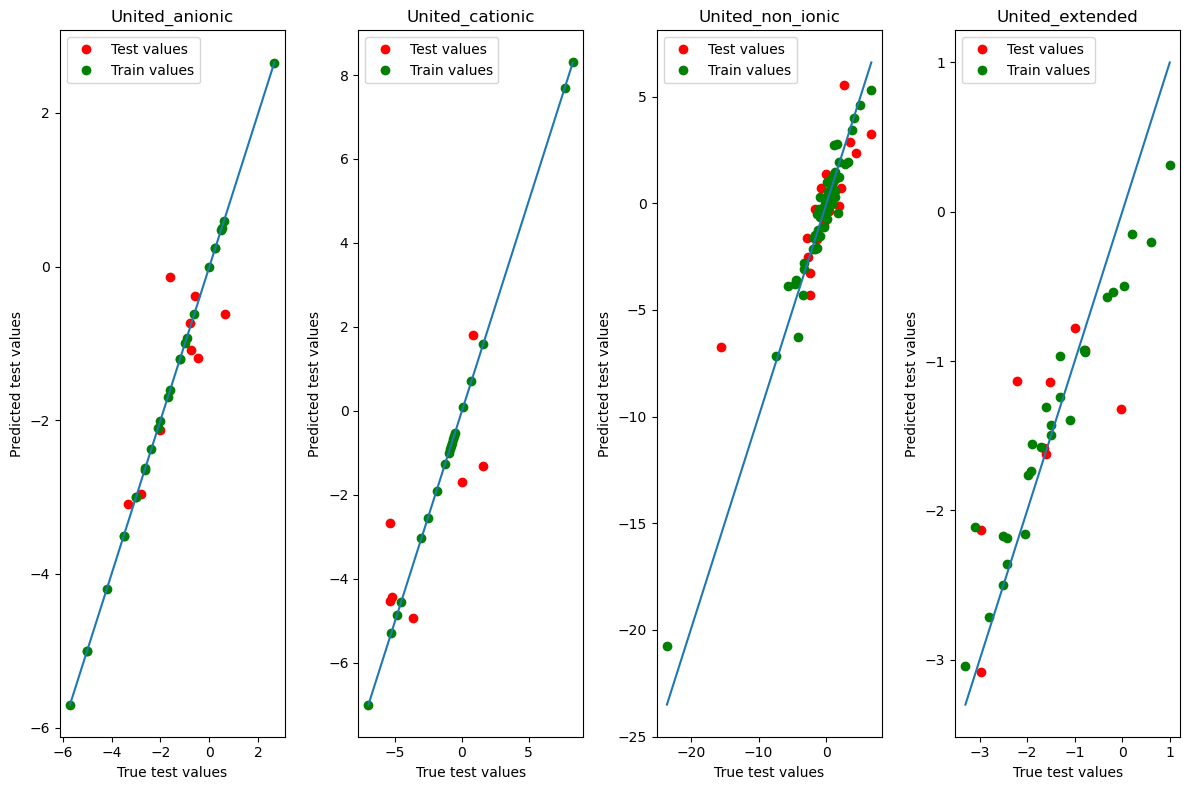

In [18]:
calculate_to_score(Ridge(max_iter = 10000), estimator_name='Linear Regression', 
                   param_grid = {'ridge__alpha':hp.loguniform(label = 'alpha', low = -4*np.log(10), high  = 2*np.log(10)),
                                'ridge__solver':hp.choice(label = 'solver', options = ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg','sag', 'saga'])}, n_iters=150)

Let's continue with other models. The first one will be
**Random Forest Classification**

In [19]:
space = {
    'randomforestregressor__max_depth': hp.randint('max_depth', 3, 15),  
    'randomforestregressor__max_features': hp.choice('max_features', [0.3, 0.5, 'sqrt', 'log2']), 
    'randomforestregressor__min_samples_split': hp.randint('min_samples_split', 5, 20),  
    'randomforestregressor__min_samples_leaf': hp.randint('min_samples_leaf', 3, 10), 
    'randomforestregressor__criterion': hp.choice('criterion', ["squared_error", "absolute_error"]), 
    'randomforestregressor__ccp_alpha': hp.uniform('ccp_alpha', 0, 0.1),  
    'randomforestregressor__n_estimators': hp.randint('n_estimators', 50, 200),  
    'randomforestregressor__bootstrap': hp.choice('bootstrap', [True]),  
    'randomforestregressor__max_samples': hp.uniform('max_samples', 0.6, 0.95)} 

100%|██████████| 50/50 [02:10<00:00,  2.61s/trial, best loss: 1.2520503166222123]
{'bootstrap': 0, 'ccp_alpha': 0.008515395850233254, 'criterion': 0, 'max_depth': 4, 'max_features': 0, 'max_samples': 0.8364802635107033, 'min_samples_leaf': 4, 'min_samples_split': 9, 'n_estimators': 196}
100%|██████████| 50/50 [02:04<00:00,  2.49s/trial, best loss: 2.3816765897202545]
{'bootstrap': 0, 'ccp_alpha': 0.07831403370203553, 'criterion': 0, 'max_depth': 9, 'max_features': 2, 'max_samples': 0.894198020594588, 'min_samples_leaf': 4, 'min_samples_split': 8, 'n_estimators': 88}
100%|██████████| 50/50 [02:09<00:00,  2.59s/trial, best loss: 1.4047524141559937]
{'bootstrap': 0, 'ccp_alpha': 0.04676845966753696, 'criterion': 0, 'max_depth': 9, 'max_features': 0, 'max_samples': 0.6271959764063777, 'min_samples_leaf': 6, 'min_samples_split': 16, 'n_estimators': 183}
100%|██████████| 50/50 [02:07<00:00,  2.55s/trial, best loss: 0.759978858974359] 
{'bootstrap': 0, 'ccp_alpha': 0.035324818269871536, 'crit

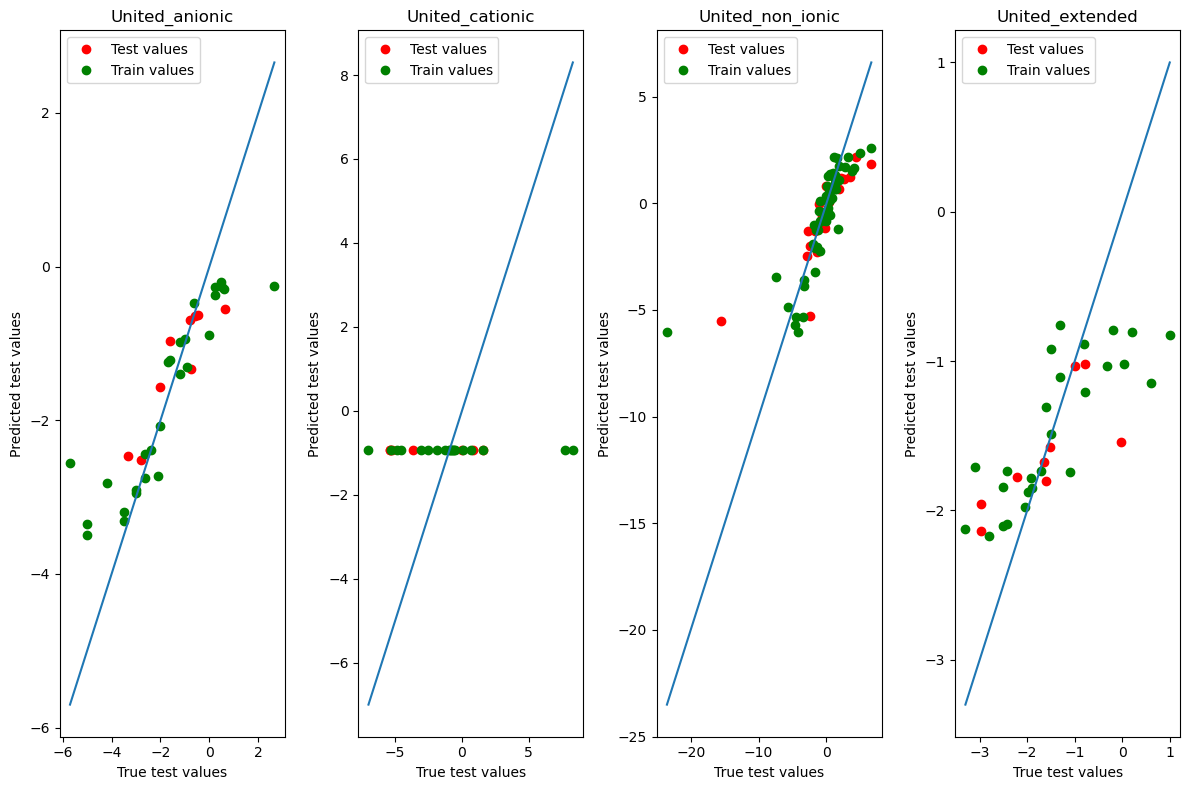

In [20]:
calculate_to_score(RandomForestRegressor(random_state = 0, n_jobs=-1), estimator_name = 'Random Forest', param_grid =  space)
               

**LightGBM**

In [21]:
space = {'lgbmregressor__max_depth':hp.randint('max_depth', 3, 12),
        'lgbmregressor__boosting_type':hp.choice('boosting_type', ['gbdt']),
        'lgbmregressor__reg_alpha':hp.loguniform('reg_alpha', -3*np.log(10), 1*np.log(10)),
         'lgbmregressor__reg_lamdba':hp.loguniform('reg_lambda', -3*np.log(10), 1*np.log(10)),
        'lgbmregressor__learning_rate':hp.loguniform('learning_rate', -3*np.log(10), 1*np.log(10)),
        'lgbmregressor__n_estimators':hp.randint('n_estimators', 50, 300),
        'lgbmregressor__n_leaves':hp.randint('n_leaves', 10, 50),
        'lgbmregressor__min_child_samples': hp.randint('min_child_samples', 5, 30)}

100%|██████████| 50/50 [00:19<00:00,  2.51trial/s, best loss: 1.0656325606100983]
{'boosting_type': 0, 'learning_rate': 0.15376095599867642, 'max_depth': 3, 'min_child_samples': 5, 'n_estimators': 50, 'n_leaves': 48, 'reg_alpha': 0.014661275887593259, 'reg_lambda': 1.927848199110596}
100%|██████████| 50/50 [00:17<00:00,  2.84trial/s, best loss: 2.3249953058942854]
{'boosting_type': 0, 'learning_rate': 0.009554297617754514, 'max_depth': 5, 'min_child_samples': 5, 'n_estimators': 263, 'n_leaves': 26, 'reg_alpha': 0.0012066042454685131, 'reg_lambda': 0.3530694945756181}
100%|██████████| 50/50 [00:35<00:00,  1.40trial/s, best loss: 1.4836551678999699]
{'boosting_type': 0, 'learning_rate': 0.09106176960669869, 'max_depth': 6, 'min_child_samples': 13, 'n_estimators': 65, 'n_leaves': 32, 'reg_alpha': 0.036317475098063344, 'reg_lambda': 0.034615441769396064}
100%|██████████| 50/50 [00:22<00:00,  2.26trial/s, best loss: 0.7461757347468226]
{'boosting_type': 0, 'learning_rate': 0.018966400993928

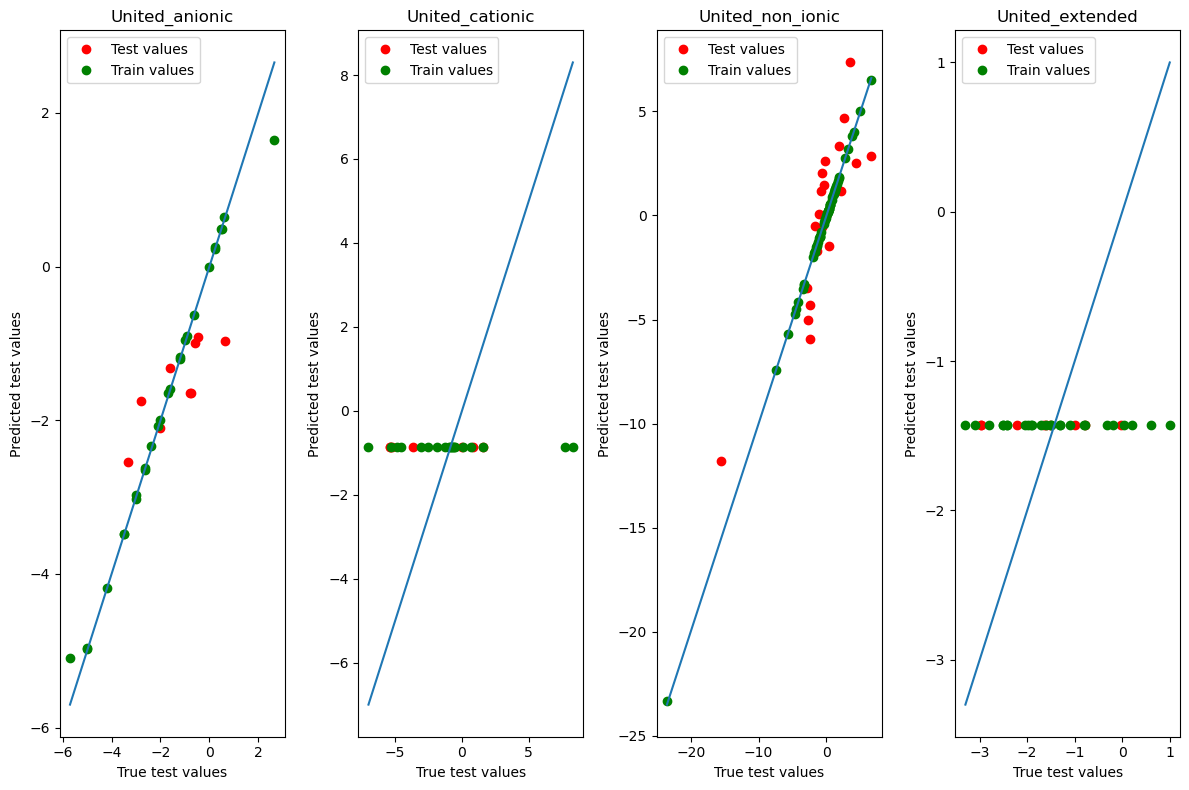

In [22]:
calculate_to_score(LGBMRegressor(verbosity = -1), estimator_name='Gradient boosting', param_grid = space)

**SVM**

In [23]:
space = {'svr__C':hp.loguniform('C', -2*np.log(10), 1*np.log(10)),
         'svr__kernel':hp.choice('kernel', ['rbf','poly','linear', 'sigmoid']),
         'svr__degree':hp.choice('degree', [2,3,4]),
         'svr__gamma':hp.choice('gamma', ['scale', 'auto']),
         'svr__coef0':hp.loguniform('coef0', -1, 1)}


100%|██████████| 50/50 [00:10<00:00,  4.95trial/s, best loss: 1.063448249874135] 
{'C': 0.02054963690988113, 'coef0': 2.265569063050639, 'degree': 2, 'gamma': 0, 'kernel': 2}
100%|██████████| 50/50 [00:09<00:00,  5.32trial/s, best loss: 1.5929094585495938]
{'C': 0.08353956113226023, 'coef0': 2.4732253561706847, 'degree': 2, 'gamma': 1, 'kernel': 2}
100%|██████████| 50/50 [00:11<00:00,  4.23trial/s, best loss: 1.4097195157692735]
{'C': 6.847539173448679, 'coef0': 0.4007649790612877, 'degree': 1, 'gamma': 1, 'kernel': 1}
100%|██████████| 50/50 [00:10<00:00,  4.57trial/s, best loss: 0.653583112722109] 
{'C': 1.1128338178589823, 'coef0': 1.4647408711985896, 'degree': 1, 'gamma': 1, 'kernel': 1}


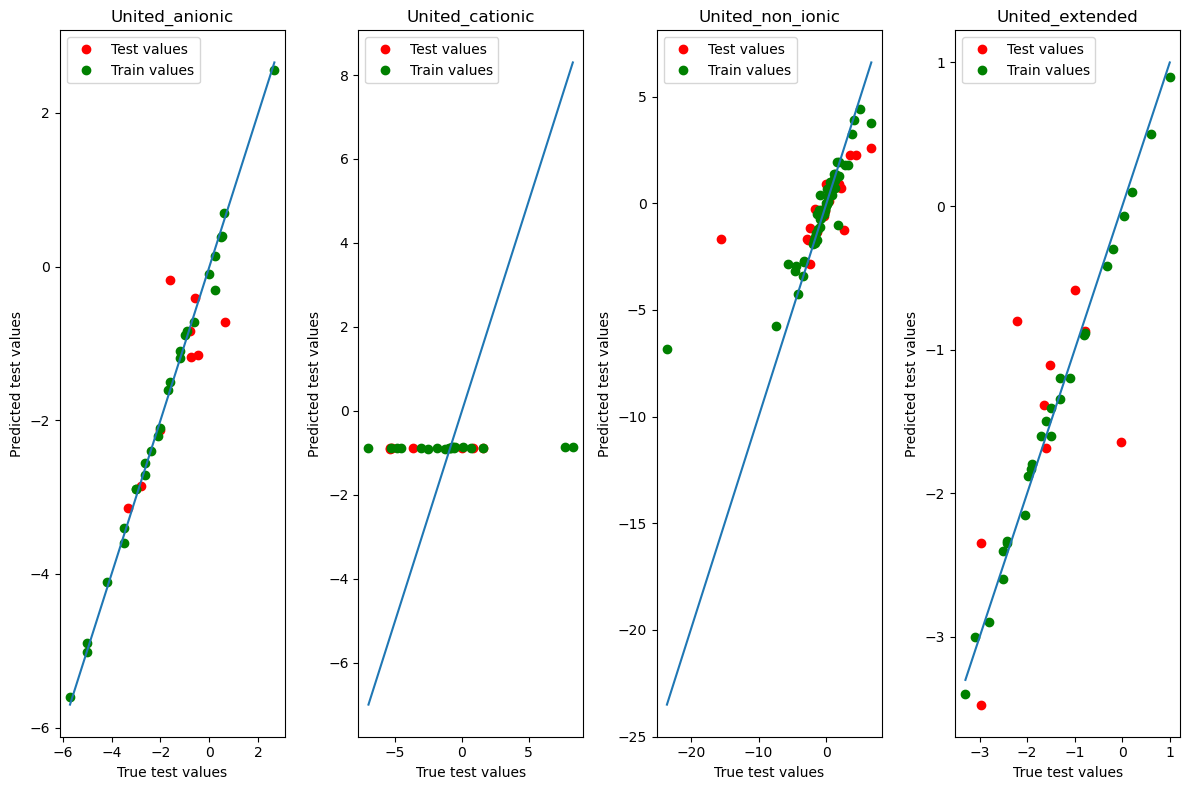

In [24]:
calculate_to_score(SVR(max_iter = 25000), estimator_name = 'SVR', param_grid = space)
                                                                


**KNearestneighbors**

In [25]:
space = {
    'kneighborsregressor__n_neighbors': hp.randint('n_neighbors', 3, 16),  # Увеличил диапазон
    'kneighborsregressor__weights': hp.choice('weights', ['uniform', 'distance']),
    'kneighborsregressor__metric': hp.choice('metric', ['minkowski', 'euclidean', 'manhattan']),  # Упростил выбор
    'kneighborsregressor__p': hp.uniform('p', 1, 3),  # Параметр для minkowski
    'kneighborsregressor__algorithm': hp.choice('algorithm', ['auto', 'ball_tree', 'kd_tree']),
    'kneighborsregressor__leaf_size': hp.randint('leaf_size', 10, 50)  # Для tree-based алгоритмов
}

100%|██████████| 50/50 [00:10<00:00,  4.87trial/s, best loss: 0.9634122408541421]
{'algorithm': 2, 'leaf_size': 32, 'metric': 2, 'n_neighbors': 4, 'p': 1.4651314698453264, 'weights': 1}
100%|██████████| 50/50 [00:09<00:00,  5.24trial/s, best loss: 2.3766469464923006]
{'algorithm': 1, 'leaf_size': 16, 'metric': 2, 'n_neighbors': 3, 'p': 1.2571329026948148, 'weights': 1}
100%|██████████| 50/50 [00:11<00:00,  4.34trial/s, best loss: 1.547571681034066]
{'algorithm': 2, 'leaf_size': 23, 'metric': 2, 'n_neighbors': 10, 'p': 1.7884867557986117, 'weights': 1}
100%|██████████| 50/50 [00:11<00:00,  4.48trial/s, best loss: 0.7199913170786315]
{'algorithm': 2, 'leaf_size': 43, 'metric': 2, 'n_neighbors': 3, 'p': 2.1138109455813594, 'weights': 1}


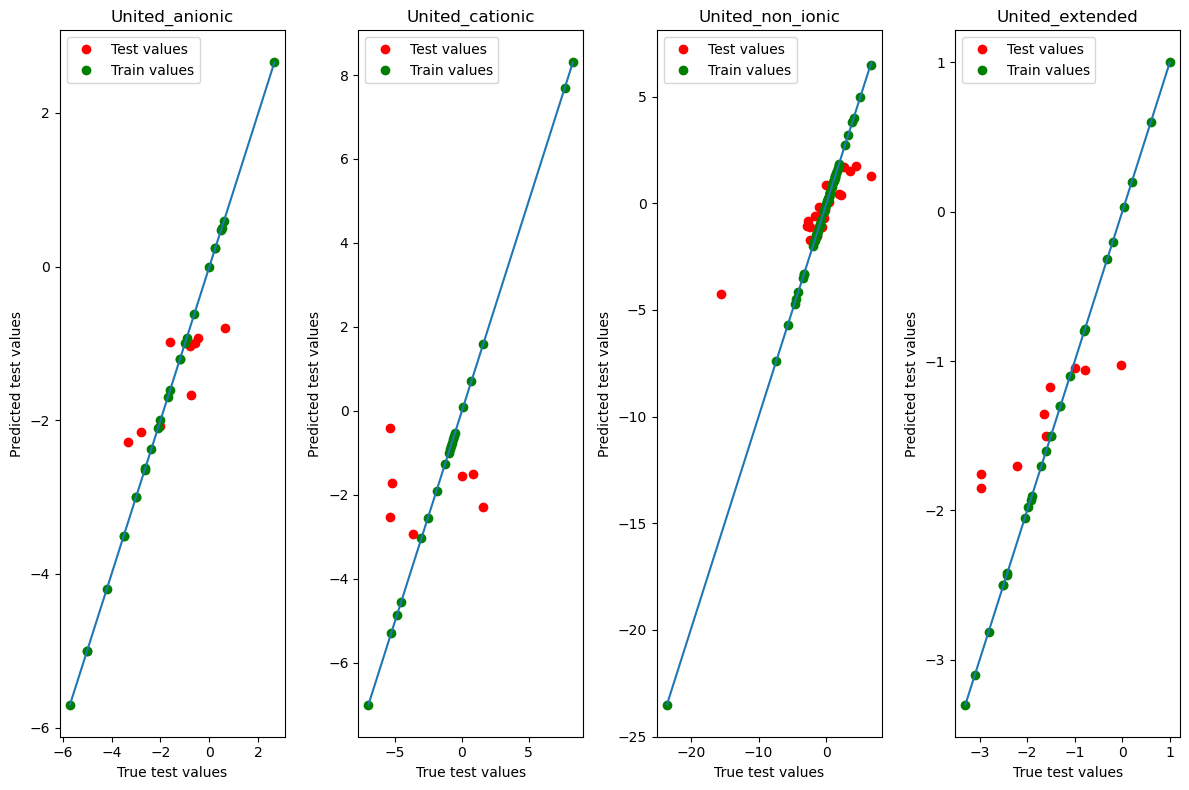

In [26]:
calculate_to_score(KNeighborsRegressor(), estimator_name='KMeans', param_grid=space)

Let's save results into pickle file and show the final scores model in readable format

In [45]:
with open('scores_united_descs.pickle', 'wb') as output:
    pickle.dump(scores, output)

In [27]:
pd.DataFrame(scores_anionic)

,Descriptors,Estimator,R2_cv,MAE_cv,RMSE_cv,R2_test,RMSE_test,MAE_test,R2_train,RMSE_train,MAE_train
0,United,Linear Regression,0.304545,1.050213,1.276837,0.639379,0.706146,0.505163,0.999999,0.001416,0.000948
1,United,Random Forest,0.251117,1.252050,1.300684,0.738873,0.600890,0.481400,0.712198,1.048777,0.681240
2,United,Gradient boosting,0.296013,1.065633,1.280735,0.497335,0.833696,0.708108,0.986321,0.228650,0.081080
3,United,SVR,0.306030,1.063448,1.276155,0.631910,0.713421,0.494793,0.994945,0.138991,0.107064
4,United,KMeans,0.432361,0.963412,1.213630,0.581522,0.760685,0.642802,1.000000,0.000000,0.000000


In [28]:
pd.DataFrame(scores_cationic)

,Descriptors,Estimator,R2_cv,MAE_cv,RMSE_cv,R2_test,RMSE_test,MAE_test,R2_train,RMSE_train,MAE_train
0,United,Linear Regression,0.662816,1.573896,1.450756,0.624356,1.791425,1.594642,1.000000,0.000089,0.000067
1,United,Random Forest,-0.018033,2.381677,1.912354,-0.272844,3.297601,3.030046,-0.000348,3.625191,2.371951
2,United,Gradient boosting,0.051632,2.324995,1.878763,-0.297533,3.329428,3.039700,0.000000,3.624561,2.368233
3,United,SVR,0.660563,1.592909,1.453174,-0.290521,3.320419,3.037364,0.005234,3.615063,2.357691
4,United,KMeans,0.200717,2.376647,1.800126,-0.148733,3.132708,2.840941,1.000000,0.000000,0.000000


In [29]:
pd.DataFrame(scores_non_ionic)

,Descriptors,Estimator,R2_cv,MAE_cv,RMSE_cv,R2_test,RMSE_test,MAE_test,R2_train,RMSE_train,MAE_train
0,United,Linear Regression,0.565031,1.523083,1.584803,0.661564,2.412534,1.543010,0.953974,0.816999,0.582507
1,United,Random Forest,0.265210,1.404752,1.806764,0.574346,2.705600,1.603009,0.557838,2.532284,1.093526
2,United,Gradient boosting,0.376313,1.483655,1.734213,0.712046,2.225344,1.908981,0.999967,0.022025,0.007752
3,United,SVR,0.566238,1.409720,1.583703,0.332797,3.387383,1.710619,0.641697,2.279538,0.733105
4,United,KMeans,0.239738,1.547572,1.822223,0.483081,2.981581,1.698485,1.000000,0.000000,0.000000


In [30]:
pd.DataFrame(scores_extended)

,Descriptors,Estimator,R2_cv,MAE_cv,RMSE_cv,R2_test,RMSE_test,MAE_test,R2_train,RMSE_train,MAE_train
0,United,Linear Regression,0.296782,0.639234,0.966571,0.501128,0.649843,0.462801,0.891881,0.366332,0.280107
1,United,Random Forest,0.052454,0.759979,1.041385,0.436597,0.690595,0.481934,0.514372,0.776380,0.592749
2,United,Gradient boosting,0.117084,0.746176,1.023154,-0.052142,0.943737,0.760400,0.000000,1.114096,0.905194
3,United,SVR,0.306494,0.653583,0.963216,0.252561,0.795430,0.603142,0.992418,0.097011,0.096330
4,United,KMeans,0.146927,0.719991,1.014397,0.437138,0.690263,0.547830,1.000000,0.000000,0.000000
